# Introduction to Seaborn

Why: Seaborn is built on top of Matplotlib but focuses on statistics, relationships, and style defaults.
It comes with built-in datasets, so we can learn without loading external files.


The tips dataset is about restaurant bills, tips, and customer demographics.

# 1. Getting started with Seaborn

https://seaborn.pydata.org/

In [1]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Load the "tips" dataset (built into Seaborn)
df = sns.load_dataset("tips")
df.head()


,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


# 2. Simpler Plots

Why useful:


1.   Histograms → understand distribution.
2.   Countplots → quick frequency counts (great for categories).

https://seaborn.pydata.org/generated/seaborn.histplot.html

https://seaborn.pydata.org/generated/seaborn.countplot.html

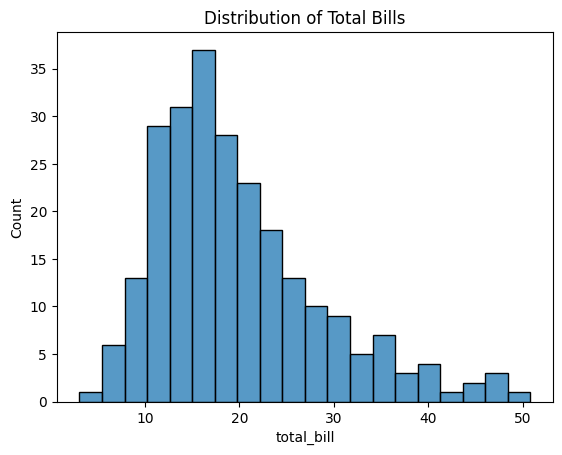

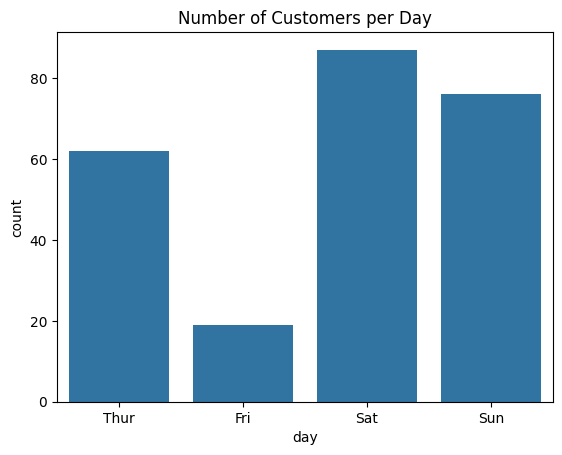

In [3]:
# Histogram of total bills
sns.histplot(df["total_bill"], bins=20, kde=False)
plt.title("Distribution of Total Bills")
plt.show()

# Countplot of customers by day
sns.countplot(data=df, x="day")
plt.title("Number of Customers per Day")
plt.show()


# 3. Rich encodings (Seaborn’s strength)

In real data, you rarely look at just 2 columns. Seaborn makes it easy to show 4–5 variables at once using color, size, and shape.

What hue does
The hue parameter assigns different colors to categories of a variable.
It tells Seaborn: “split this plot by groups and show them in different colors.”
Works in many plot types: scatterplot, barplot, lineplot, boxplot, etc.

https://seaborn.pydata.org/generated/seaborn.scatterplot.html



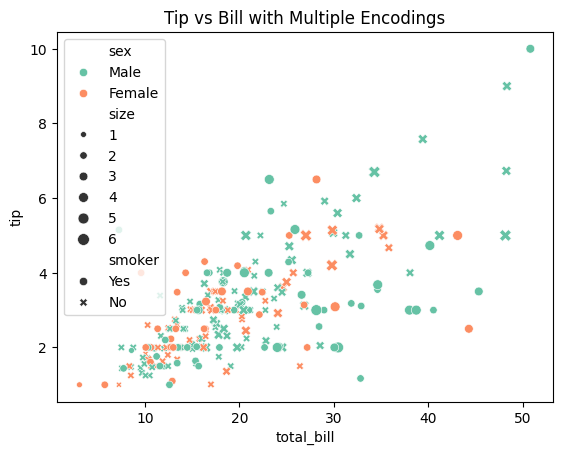

In [4]:
sns.scatterplot(
    data=df,
    x="total_bill", y="tip",
    hue="sex", style="smoker", size="size", palette="Set2"
)
plt.title("Tip vs Bill with Multiple Encodings")
plt.show()


# 4. Statistical relationships

Unlike Matplotlib, Seaborn can add regression lines + confidence intervals automatically → very handy for data analysis.

https://seaborn.pydata.org/generated/seaborn.lmplot.html

What col does:


*   In Seaborn’s figure-level functions (lmplot, catplot, relplot, etc.),
the parameter col splits your data into subplots (columns) based on a categorical variable.
*   Each unique value of the variable you pass to col gets its own panel.


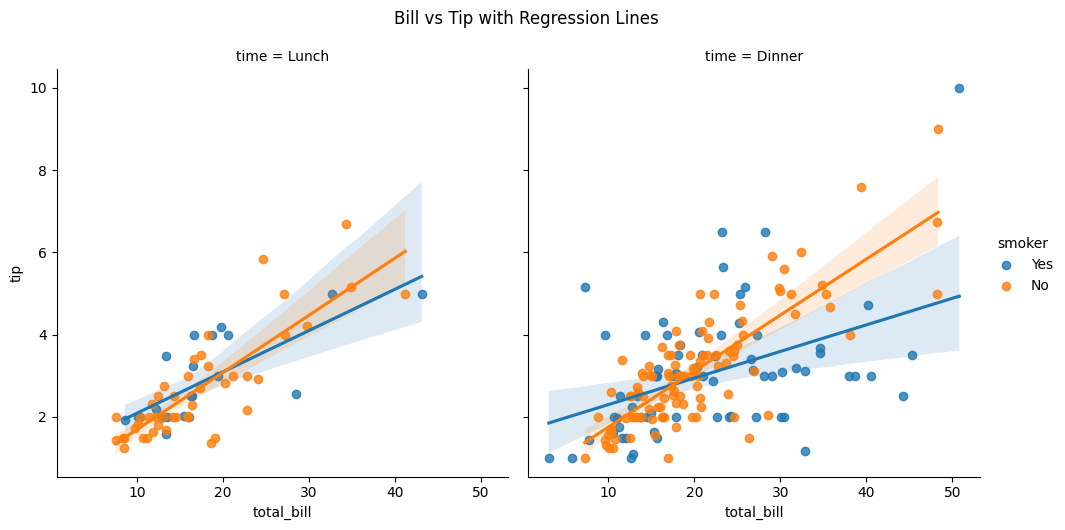

In [5]:
sns.lmplot(data=df, x="total_bill", y="tip", hue="smoker", col="time")
plt.suptitle("Bill vs Tip with Regression Lines", y=1.05)
plt.show()


# 5. Heatmaps (business-style insight)



Heatmaps are common in analytics dashboards. This example shows how tips vary by day and group size.

https://pandas.pydata.org/docs/reference/api/pandas.pivot_table.html

https://seaborn.pydata.org/generated/seaborn.heatmap.html

/tmp/ipython-input-723175263.py:1: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pivot = df.pivot_table(values="tip", index="day", columns="size", aggfunc="mean")


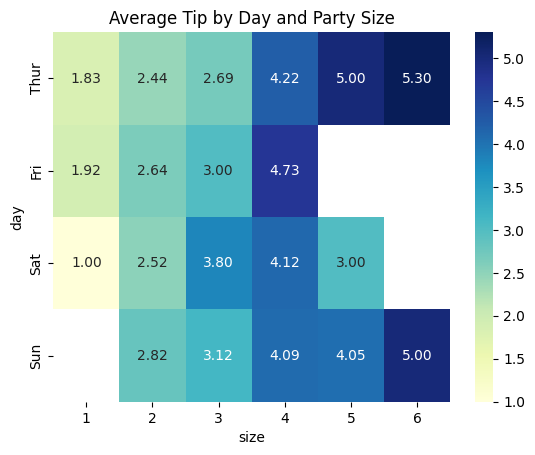

In [6]:
pivot = df.pivot_table(values="tip", index="day", columns="size", aggfunc="mean")
sns.heatmap(pivot, annot=True, cmap="YlGnBu", fmt=".2f")
plt.title("Average Tip by Day and Party Size")
plt.show()


# 6. Pairwise exploration

With one line, you get an overview of relationships between multiple numeric variables. Great for EDA (exploratory data analysis).

https://seaborn.pydata.org/generated/seaborn.pairplot.html

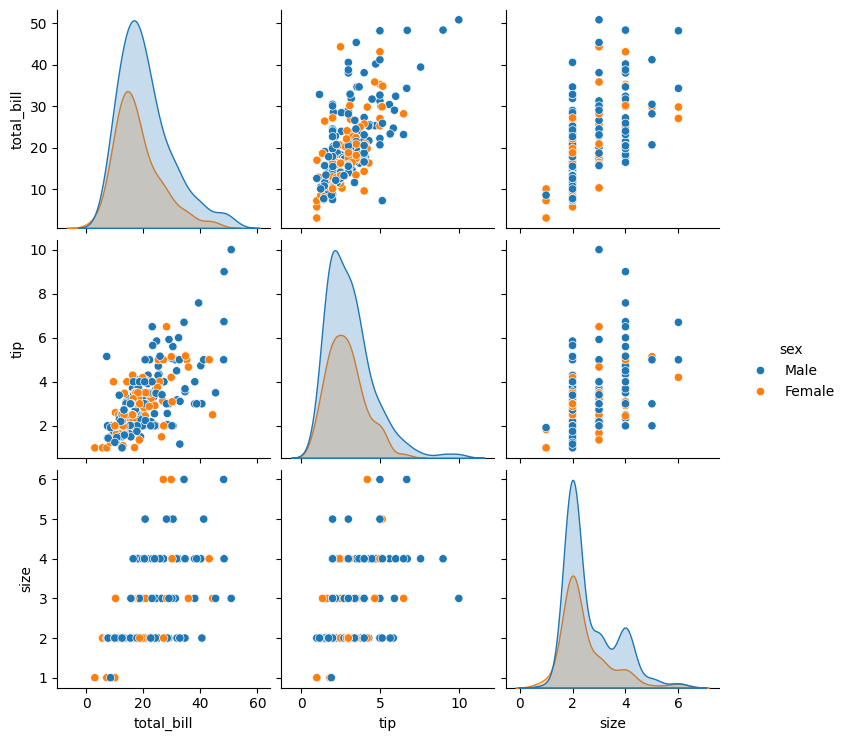

In [7]:
sns.pairplot(df, vars=["total_bill", "tip", "size"], hue="sex")
plt.show()


# 7. Faceting

Faceting allows us to break data into subplots automatically. We see how to compare groups side by side without manual loops.

https://seaborn.pydata.org/generated/seaborn.catplot.html

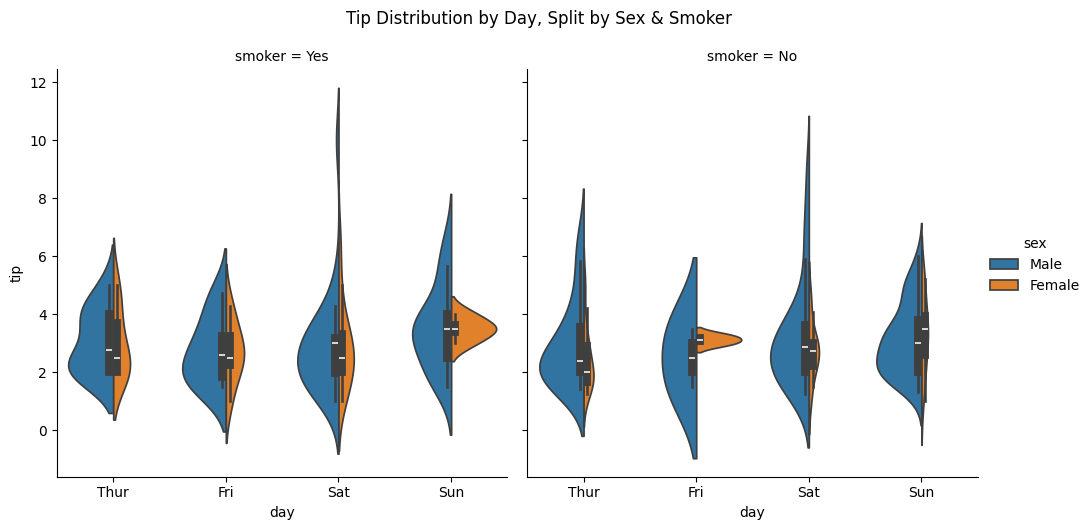

In [8]:
g = sns.catplot(
    data=df, x="day", y="tip", kind="violin",
    hue="sex", col="smoker", split=True
)
g.fig.suptitle("Tip Distribution by Day, Split by Sex & Smoker", y=1.05)
plt.show()


# 8. Styling & polish

In practice, plots go into reports or slides. With style, palette, and context, we can make charts publication-ready easily.

context in Seaborn controls the scaling of plot elements (fonts, line widths, markers, etc.) so your chart looks right depending on where you’ll use it.

The four built-in contexts:


1.   paper → for small plots, optimized for use in papers or tight layouts. Small fonts, thin lines.
2.   notebook → the default. Balanced for interactive use (Jupyter/Colab).
3. talk → larger fonts, thicker lines. Good for teaching, presentations, or projecting in class.
4. poster → extra-large scaling, best for posters or slides viewed from far away.

https://seaborn.pydata.org/generated/seaborn.set_theme.html

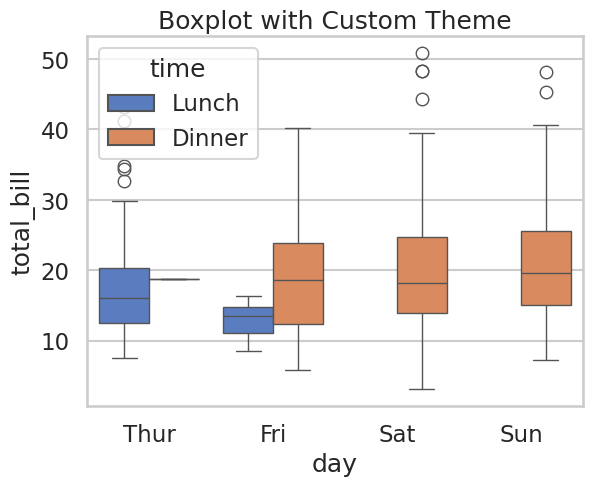

In [13]:
sns.set_theme(style="whitegrid", palette="muted", context="talk")

sns.boxplot(data=df, x="day", y="total_bill", hue="time")
plt.title("Boxplot with Custom Theme")
plt.show()
